# Full synthetic aperture imaging with L7-4 linear transducer

This notebook demonstrates full synthetic aperture imaging using a linear transducer model of the L7-4 probe. The simulation uses the Fullwave25 package to simulate ultrasound wave propagation and the mach-beamform package for beamforming the received signals.


## Installation

To run this notebook, ensure you have the required packages installed. You can install them using pip:

```bash
pip install -U fullwave25
pip install cupy
pip install pymust
pip install mach-beamform
```


In [1]:
# For Google Colab users, please uncomment
# and run the following lines to install the required packages:
# You may need to restart the runtime after installation.

# !pip install -U fullwave25
# !pip install cupy
# !pip install pymust
# !pip install mach-beamform

## Basic steps

1. Preparation
   1. Import necessary libraries and modules.
   2. Define the working directory.
2. Simulation configuration
   1. Define the computational grid parameters. (`fullwave.Grid`)
   2. Define the acoustic medium properties. (`fullwave.Medium`)
   3. Define the transducer properties (`fullwave.Transducer`)
3. Simulation setup
   1. Initialize the Fullwave solver object with the defined parameters. (`fullwave.Solver`)
   2. Execute the simulation.
4. Post-process
   1. Load the recorded wavefield data.
   2. Beamform the data using Mach-Beamform package.
   3. Visualize the results.


## Step 1: Preparation

### Step 1.1: Import necessary libraries and modules

In this step, we import the required libraries and modules for the simulation. We use `pathlib` for handling file paths, `numpy` for numerical operations, `fullwave` along with its utility functions for wave propagation simulations and data visualization, and `mach` for beamforming the recorded signals.


In [2]:
import shutil
from pathlib import Path

import cupy
import numpy as np
import pymust
from einops import rearrange
from mach import experimental, wavefront
from mach.io.must import (
    linear_probe_positions,
    scan_grid,
)
from tqdm import tqdm

import fullwave
from fullwave.utils import plot_utils

2026-01-21 13:48:50 GMT - INFO - __init__.py | <module> | 66 - Fullwave version: 1.1.3


### Step 1.2: Define the working directory

In this step, we set up the working directory where simulation outputs will be saved.
Using the `Path` module from the `pathlib` library, we define the path to the working directory.


In [3]:
# we will make a working directory called "synthetic_aperture" inside "outputs" directory.
work_dir = Path("./outputs/") / "synthetic_aperture"

# create the working directory if it does not exist
work_dir.mkdir(parents=True, exist_ok=True)

## Step 2

### Step 2.1: Define the computational grid parameters. (`fullwave.Grid`)

`fullwave.Grid` defines the computational domain where the simulation takes place spatially and temporally.

In this step, we define the computational grid parameters using the `fullwave.Grid` class. This includes specifying the domain size (`domain_size`) in meters, center frequency (`f0`) of the source in Hz, base sound speed (`c0`) in m/s, and duration (`duration`) of the simulation in seconds.

As an optional step, we can also define spatial resolution (`ppw`) and temporal resolution (`cfl`). If not specified, these will be set to default values.
But usually the default values are sufficient, which are cfl=0.2 and ppw=12.


In [4]:
domain_size = (4.5e-2, 4.5e-2)  # [axial, lateral] meters
f0 = 2e6
c0 = 1540
duration = domain_size[0] / c0 * 2.3
ppw = 12
cfl = 0.4

grid = fullwave.Grid(domain_size, f0, duration, c0=c0, ppw=ppw, cfl=cfl)

In [5]:
grid.summary()

Grid Information:
  Domain size (axial, lateral) (grid.domain_size): (4.50e-02 m, 4.50e-02 m)
  Center frequency: (grid.f0) 2.0 MHz
  Duration: (grid.duration) 6.72e-05 s
  Speed of sound (grid.c0): 1540 m/s
  Points per wavelength (PPW) (grid.ppw): 12
  Courant-Friedrichs-Lewy (CFL) number (grid.cfl): 0.4
  Wavelength (grid.wavelength): 7.70e-01 m
  Grid spacing (grid.dx, grid.dy): (6.42e-02 m, 6.42e-02 m)
  Number of grid points (grid.nx, grid.ny): (701, 701)
  Time step (grid.dt): 1.67e-08 sec
  Number of time steps (grid.nt): 4032
  is 3D simulation (grid.is_3d): False


### Step 2.2: Define the acoustic medium properties. (`fullwave.Medium`)

`fullwave.Medium` defines the physical properties of the medium where the wave propagates.

In this step, we define the acoustic medium properties using the `fullwave.Medium` class.

We specify the sound speed (`c`), density (`rho`), attenuation coefficient (`alpha_coeff`), attenuation power law exponent (`alpha_power`), and nonlinearity parameter (`beta`) of the medium as 2D NumPy arrays.

In this example, the medium is initialized with a uniform value, and an echoic targets are added.

we are using `np.ones` function to create arrays filled with ones, and then multiplying them by the desired values to create uniform property distributions.


In [6]:
sound_speed_map = np.ones(grid.shape) * c0
density_map = np.ones(grid.shape) * 1000
alpha_coeff_map = np.ones(grid.shape) * 0.5  # dB/(MHz^y cm)
alpha_power_map = np.ones(grid.shape) * 1.1  # y
beta_map = np.ones(grid.shape) * 0  # nonlinearity parameter
air_map = np.zeros(grid.shape)  # no air bubbles

We generate scatterer using `fullwave.util.generate_scatterer` function, which creates a random distribution of scatterers in the medium to simulate speckle noise in ultrasound imaging.

`np.random.default_rng` is used to create a random number generator with a fixed seed for reproducibility.
`rng` can be used to generate random numbers in a controlled manner.
`rng` is then passed to the `generate_scatterer` function to ensure that the generated scatterers are consistent across different runs of the simulation.


In [7]:
# create a random number generator with a fixed seed for reproducibility
rng = np.random.default_rng(seed=42)

# generate scatterer
scatterer, _ = fullwave.utils.generate_scatterer(
    grid=grid,
    ratio_scatterer_to_total_grid=0.38,
    scatter_value_std=0.02 / 2,
    rng=rng,
)

We define `make_echoic_target` function to add echoic targets to the medium properties. This function modifies the sound speed, density, attenuation coefficient, attenuation power law exponent, and nonlinearity parameter within a specified circular region to simulate an echoic target.


In [8]:
def make_echoic_targets(
    scatterer: np.ndarray,
    grid: fullwave.Grid,
    target_radius_m: float,
    target_spacing_m: float,
    start_offset_x_m: float,
    start_offset_y_m: float,
    n_targets_axial: int,
    n_targets_lateral: int,
    *,
    centered: bool = True,
) -> np.ndarray:
    """Place echoic circles in the scatter map.

    Parameters
    ----------
    scatterer : np.ndarray
        Scatterer map to modify.
    grid : fullwave.Grid
        Computational grid.
    target_radius_m : float
        Radius of each target in meters.
    target_spacing_m : float
        Spacing between targets in meters.
    start_offset_x_m : float
        Starting offset in the axial direction in meters.
    start_offset_y_m : float
        Starting offset in the lateral direction in meters.
    n_targets_axial : int
        Number of targets in the axial direction.
    n_targets_lateral : int
        Number of targets in the lateral direction.
    centered : bool, optional
        Whether to center the targets in the grid (default: True).

    Returns
    -------
    np.ndarray
        Modified scatterer map with echoic targets.

    """
    # place echoic circles in the scatter map
    # each circle has a target_radius_m and is spaced by target_spacing_m
    if centered:
        total_axial_length = (n_targets_axial - 1) * target_spacing_m
        total_lateral_length = (n_targets_lateral - 1) * target_spacing_m
        start_offset_x_m = (grid.shape[0] * grid.dx - total_axial_length) / 2
        start_offset_y_m = (grid.shape[1] * grid.dx - total_lateral_length) / 2

    axial_positions = np.linspace(
        start_offset_x_m,
        start_offset_x_m + (n_targets_axial - 1) * target_spacing_m,
        n_targets_axial,
        endpoint=True,
    )
    lateral_positions = np.linspace(
        start_offset_y_m,
        start_offset_y_m + (n_targets_lateral - 1) * target_spacing_m,
        n_targets_lateral,
        endpoint=True,
    )

    echoic_target_max = 4
    echoic_target_min = 2

    hypo_echoic_target_max = 0.6
    hypo_echoic_target_min = 0.4

    anechoic_target_max = 0.0
    anechoic_target_min = 0.0
    hyper_echoic_ratio_array = np.linspace(
        echoic_target_max,
        echoic_target_min,
        n_targets_axial,
    )
    hypo_echoic_ratio_array = np.linspace(
        hypo_echoic_target_max,
        hypo_echoic_target_min,
        n_targets_axial,
    )
    anechoic_ratio_array = np.linspace(
        anechoic_target_max,
        anechoic_target_min,
        n_targets_axial,
    )
    echoic_ratio_array = np.zeros((n_targets_axial, n_targets_lateral))
    for i in range(n_targets_axial):
        echoic_ratio_array[i, 0] = anechoic_ratio_array[i]
        echoic_ratio_array[i, 1] = hypo_echoic_ratio_array[i]
        echoic_ratio_array[i, 2] = hyper_echoic_ratio_array[i]

    for i_axial, axial_pos in enumerate(axial_positions):
        for i_lateral, lateral_pos in enumerate(lateral_positions):
            axial_idx = int(axial_pos / grid.dx)
            lateral_idx = int(lateral_pos / grid.dx)
            (
                rr,
                cc,
            ) = np.ogrid[
                -axial_idx : scatterer.shape[0] - axial_idx,
                -lateral_idx : scatterer.shape[1] - lateral_idx,
            ]
            circle_mask = rr**2 + cc**2 <= (target_radius_m / grid.dx) ** 2

            scatterer -= 1.0
            scatterer[circle_mask] *= echoic_ratio_array[i_axial, i_lateral]
            scatterer += 1.0

    return scatterer

We use the `make_echoic_targets` function to add multiple anechoic, hypoechoic, and hyperechoic targets at specified locations within the medium.
We modify the scatterer map to simulate the presence of these targets by setting the scatterer values.


In [9]:
scatterer = make_echoic_targets(
    scatterer=scatterer,
    grid=grid,
    target_radius_m=5e-3,
    target_spacing_m=15e-3,
    start_offset_x_m=10e-3,
    start_offset_y_m=10e-3,
    n_targets_axial=3,
    n_targets_lateral=3,
    centered=True,
)

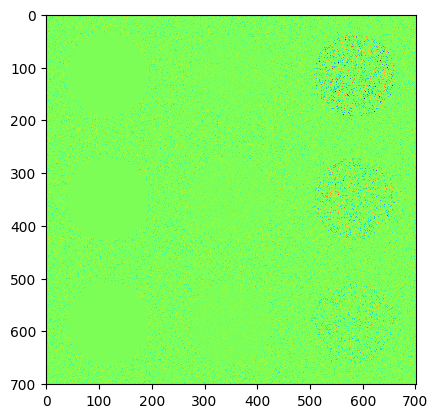

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [10]:
plot_utils.plot_array(scatterer, show=True)

We apply the scatterer map to the density map to introduce speckle noise in the medium.
Scatterer values are centered around 1.0 with small variations.


In [11]:
density_map *= scatterer

As a next step, we initialize the `Medium` object with the defined properties.


In [12]:
medium = fullwave.Medium(
    grid,
    sound_speed=sound_speed_map,
    density=density_map,
    alpha_coeff=alpha_coeff_map,
    alpha_power=alpha_power_map,
    beta=beta_map,
    air_map=air_map,
)

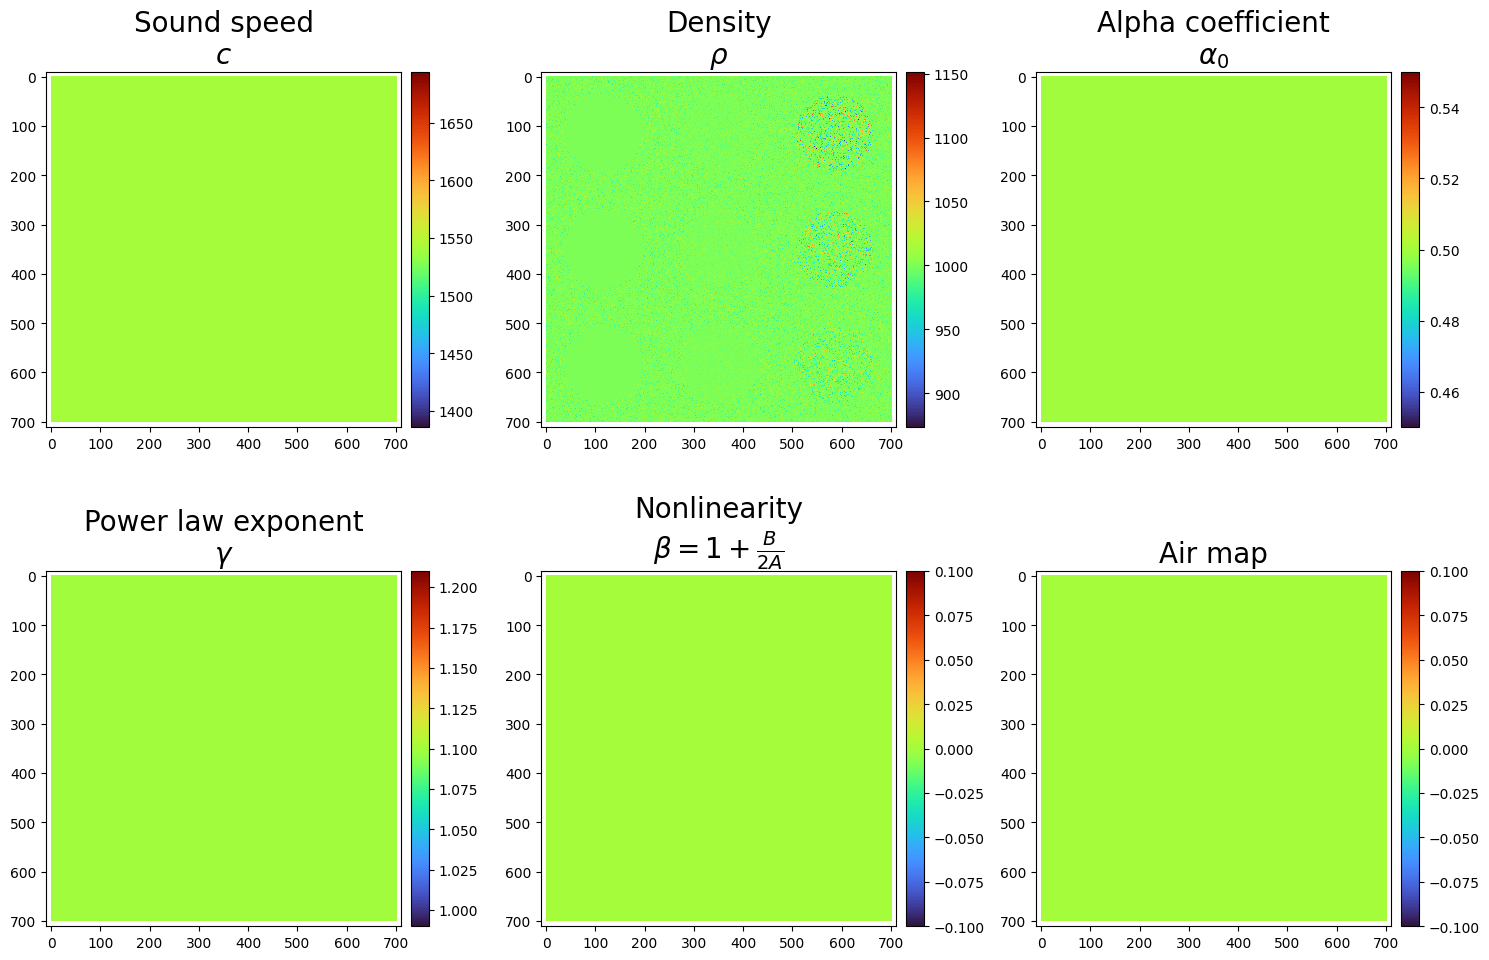

In [13]:
medium.plot(
    show=True,
    export_path=work_dir / "medium.png",
    dpi=50,
)

### Step 2.3: Define the transducer properties (`fullwave.Transducer`)

In this step, we define the transducer properties using the `fullwave.Transducer` class. This includes specifying transducer element positions, number of elements, element width, element height, kerf size, and transducer curviture radius.

For L7-4 linear transducer model, we set the number of elements to 128, element width to 0.298 - 0.048 mm, element height to 4 px, kerf size to 0.048 mm, and curviture radius to infinity (indicating a flat transducer). The element positions are calculated based on the number of elements and element width.
The origin of the transducer is set to be at the top left corner of the grid. In this example, the transducer is centered horizontally at the top of the grid.


In [14]:
element_layer_px = 4
transducer_width_m = 38e-3
transducer_geometry = fullwave.TransducerGeometry(
    grid,
    number_elements=128,
    # -
    element_width_m=0.298e-3 - 0.048e-3,
    # -
    element_spacing_m=0.048e-3,
    # -
    element_layer_px=element_layer_px,
    # -
    # [axial, lateral]
    position_m=(
        0,
        (domain_size[1] - transducer_width_m) / 2,
    ),
    # -
    radius=float("inf"),
)

We then pass the transducer geometry information to the `fullwave.Transducer` class to create the transducer object.
`sampling_interval` is set to 7 to define the temporal sampling interval for the transducer.


In [15]:
sampling_interval = 7
transducer = fullwave.Transducer(
    transducer_geometry=transducer_geometry,
    grid=grid,
    sampling_modulus_time=sampling_interval,
)

Now, let's take a look at the transduce elements by plotting the source mask of the transducer.


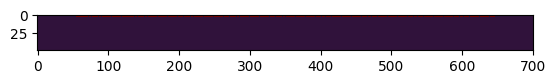

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [16]:
plot_utils.plot_array(transducer.source_mask[:50, :], show=True)

If we zoom in the plot, we can clearly see the individual transducer elements and their arrangement.


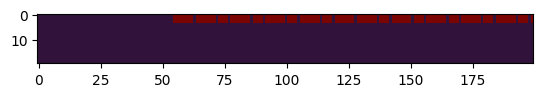

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [17]:
plot_utils.plot_array(transducer.source_mask[:20, :200], show=True)

As a next step, we will define the source signals for synthetic aperture imaging.
We will define `make_input_signal` function to create input signals for the transducer elements.

In synthetic aperture imaging, each transducer element is activated one at a time to transmit and receive ultrasound signals.
We will use the function later in the simulation execution step.


In [18]:
def make_input_signal(
    active_source_element_id: int,
    grid: fullwave.Grid,
    transducer_geometry: fullwave.TransducerGeometry,
    transducer: fullwave.Transducer,
    element_layer_px: int,
    *,
    p_max: float = 1e5,
) -> np.ndarray:
    """Generate an input signal for single element transmission.

    Parameters
    ----------
    active_source_element_id : int
        ID of the active source element.
    grid : fullwave.Grid
        Computational grid for the simulation.
    transducer_geometry : fullwave.TransducerGeometry
        Geometry of the transducer.
    transducer : fullwave.Transducer
        Transducer object containing source information.
    element_layer_px : int
        Number of pixels per element layer.
    p_max : float, optional
        Maximum pressure amplitude (default: 1e5).

    Returns
    -------
    np.ndarray
        Input signal array of shape (n_sources, nt).

    """
    active_source_elements = np.zeros(transducer_geometry.number_elements, dtype=bool)
    active_sensor_elements = np.zeros(transducer_geometry.number_elements, dtype=bool)
    active_source_elements[active_source_element_id] = True
    active_sensor_elements[:] = True

    input_signal = np.zeros((transducer.n_sources, grid.nt))
    dict_source_index_to_location = transducer.dict_source_index_to_location

    for i_source_index in range(len(input_signal)):
        delay_sec = 0
        source_location = dict_source_index_to_location[i_source_index + 1]

        n_y = input_signal.shape[0] // element_layer_px
        i_layer = i_source_index // n_y
        element_id = transducer.transducer_geometry.indexed_element_mask_input[*source_location]
        if not active_source_elements[element_id - 1]:
            p0_vec = np.zeros(grid.nt)
        else:
            p0_vec = fullwave.utils.pulse.gaussian_modulated_sinusoidal_signal(
                nt=grid.nt,
                f0=grid.f0,
                duration=grid.duration,
                ncycles=2,
                drop_off=2,
                p0=p_max,
                i_layer=i_layer,
                dt_for_layer_delay=grid.dt,
                cfl_for_layer_delay=grid.cfl,
                delay_sec=delay_sec,
            )
        input_signal[i_source_index, :] = p0_vec.copy()
    return input_signal

## Step 3. Simulation setup

The rest of the setup is mostly similar to previous examples.

### Step 3.1: Initialize the Fullwave solver object with the defined parameters. (`fullwave.Solver`)

The `Solver` class takes the working directory (`work_dir`), computational grid (`grid`), acoustic medium (`medium`), acoustic source (`source`), and sensor (`sensor`) as inputs to create a solver object that can be used to run the wave propagation simulation.

We will pass the `transducer` object instead of `source` and `sensor` arguments to the `Solver` class since the transducer acts as both the source and sensor in this simulation.

In the synthetic aperture imaging simulation, we will iterate over multiple active source element IDs to activate each transducer element one at a time for transmission and reception of ultrasound signals. We will set up a loop to run the simulation for each active source element ID and store the recorded data accordingly.

We also use `is_static_map` option to optimize the simulation since the medium properties do not change during the simulation. In this setup, it reuses the precomputed static maps for sound speed and density, which can significantly reduce computation time and memory usage. Only the input signals are updated for each angle.


In [19]:
active_source_element_id_list = list(range(128))
active_source_element_id_list = active_source_element_id_list[32::32]  # for faster demo

p_max = 1e5
remove_dir = True
sensor_output_list = []
for i_active_source_element_id, active_source_element_id in tqdm(
    enumerate(active_source_element_id_list),
    total=len(active_source_element_id_list),
):
    input_signal = make_input_signal(
        active_source_element_id=active_source_element_id,
        grid=grid,
        transducer_geometry=transducer_geometry,
        transducer=transducer,
        element_layer_px=element_layer_px,
        p_max=p_max,
    )
    transducer.set_signal(input_signal)
    fw_solver = fullwave.Solver(
        work_dir=work_dir,
        grid=grid,
        medium=medium,
        transducer=transducer,
        run_on_memory=False,
    )
    if i_active_source_element_id == 0:
        sensor_output = fw_solver.run(
            is_static_map=True,
            recalculate_pml=True,
        )
    else:
        sensor_output = fw_solver.run(
            simulation_dir_name=f"txrx_{i_active_source_element_id}",
            is_static_map=True,
            recalculate_pml=False,  # Reuse PML from first run
        )
    sensor_output = fw_solver.transducer.post_process_sensor_output(
        sensor_output,
        average_surface_signals=True,
    )
    sensor_output_list.append(sensor_output)
    if remove_dir is True:
        shutil.rmtree(work_dir / f"txrx_{i_active_source_element_id}")

  0%|          | 0/3 [00:00<?, ?it/s]2026-01-21 13:48:52 GMT - INFO - solver.py | run | 698 - Starting Fullwave 2.5 v1.1.3...
2026-01-21 13:48:52 GMT - INFO - input_file_writer.py | run | 145 - Generating input files for simulation...
2026-01-21 13:48:52 GMT - INFO - input_file_writer.py | run | 189 - Input files generated in 4.62e-02 seconds.
2026-01-21 13:48:52 GMT - INFO - launcher.py | run | 203 - Running simulation...
2026-01-21 13:48:57 GMT - INFO - launcher.py | run | 218 - Simulation completed in 4.73e+00 seconds.
2026-01-21 13:48:57 GMT - INFO - launcher.py | run | 245 - Loading simulation results from genout.dat...
2026-01-21 13:48:57 GMT - INFO - launcher.py | run | 250 - Loading completed in 5.58e-04 seconds.
2026-01-21 13:48:57 GMT - INFO - solver.py | run | 782 - reshaping the result...
2026-01-21 13:48:57 GMT - INFO - solver.py | run | 794 - Result reshaping completed in 6.44e-06 seconds.
 33%|███▎      | 1/3 [00:05<00:10,  5.29s/it]2026-01-21 13:48:58 GMT - INFO - solve

## Step 4: Post-process

Now that we have RF data for all angles in `sensor_output_list`, we can proceed to beamform the data using the [mach-beamform](https://github.com/Forest-Neurotech/mach) package.

mach-beamform is a Python package for ultrasound beamforming that provides ultra-fast GPU-accelerated beamforming algorithms.

We define some b-mode imaging parameters.


In [20]:
transducer_width_m = transducer.transducer_geometry.transducer_width_m

params = {
    "fs": 1 / grid.dt / sampling_interval,  # Sampling frequency (Hz)
    "fc": f0,  # Center frequency (Hz)
    "Nelements": 128,  # Number of array elements
    "pitch": transducer_width_m / 128,  # Element pitch (meters)
    "c": c0,  # Speed of sound in medium (m/s)
    # "fnumber": 1.0,
    "fnumber": 2.0,
    "t0": 0,  # Start time of data acquisition (seconds)
}

element_positions = linear_probe_positions(params["Nelements"], params["pitch"])
b_mode_x = np.linspace(-transducer_width_m / 2, transducer_width_m / 2, num=256, endpoint=True)
b_mode_y = np.array([0.0])  # 2D imaging (single y-plane)
b_mode_z = np.linspace(5e-3, domain_size[0], num=512, endpoint=True)

# make grid points for beamforming
grid_points = scan_grid(b_mode_x, b_mode_y, b_mode_z)

Then, we calculate the wavefront arrival times for each pixel in the imaging region based on the transducer geometry and the defined angles.


In [21]:
wavefront_arrivals_s = [
    wavefront.spherical(
        origin_m=element_positions[i_elem],
        points_m=grid_points,
        focus_m=element_positions[i_elem],  # FSA: focus at each element position
    )
    / params["c"]
    for i_elem in active_source_element_id_list
]
for i in range(len(wavefront_arrivals_s)):
    wavefront_arrivals_s[i] -= wavefront_arrivals_s[i].min()
wavefront_arrivals_s = np.stack(wavefront_arrivals_s, axis=0)

Now, we preprocess the convert the RF data to IQ data for beamforming.


In [22]:
sensor_output = np.stack(sensor_output_list, axis=0)
sensor_output = sensor_output.transpose(2, 1, 0)

iq_data = pymust.rf2iq(sensor_output, Fs=params["fs"], Fc=params["fc"])

# Convert to flattened grid points for beamforming
iq_data = iq_data[:, :, :, np.newaxis]
iq_data = np.ascontiguousarray(
    rearrange(
        iq_data,
        "samples elements transmit frames -> transmit elements samples frames",
    ),
    # iq_data,
    dtype=np.complex64,
)

We will execute delay-and-sum beamforming with mach-beamform to obtain the final b-mode image.


In [23]:
b_mode = experimental.beamform(
    channel_data=cupy.asarray(iq_data),  # IQ data from all elements
    rx_coords_m=cupy.asarray(element_positions),  # Array element positions
    scan_coords_m=cupy.asarray(grid_points),  # Imaging grid coordinates
    tx_wave_arrivals_s=cupy.asarray(
        wavefront_arrivals_s,
    ),  # Transmit arrival times (s)
    f_number=float(params["fnumber"]),  # Dynamic focusing f-number
    rx_start_s=float(params["t0"]),  # Data acquisition start time
    sampling_freq_hz=float(params["fs"]),  # Sampling frequency
    sound_speed_m_s=float(params["c"]),  # Medium sound speed
    modulation_freq_hz=float(params["fc"]),  # Demodulation frequency
    tukey_alpha=0.5,  # No additional windowing
)

# convert cupy to numpy
b_mode = cupy.asnumpy(b_mode)
b_mode = b_mode.reshape(len(b_mode_x), len(b_mode_z))

Here is the obtained IQ data before B-mode conversion.


In [24]:
def convert_to_db(signal: np.ndarray) -> np.ndarray:
    """Convert signal to decibel scale.

    Parameters
    ----------
    signal : np.ndarray
        Input signal array.

    Returns
    -------
    np.ndarray
        Signal in decibel scale.

    """
    return 20 * np.log10(np.abs(signal) / np.max(np.abs(signal)))

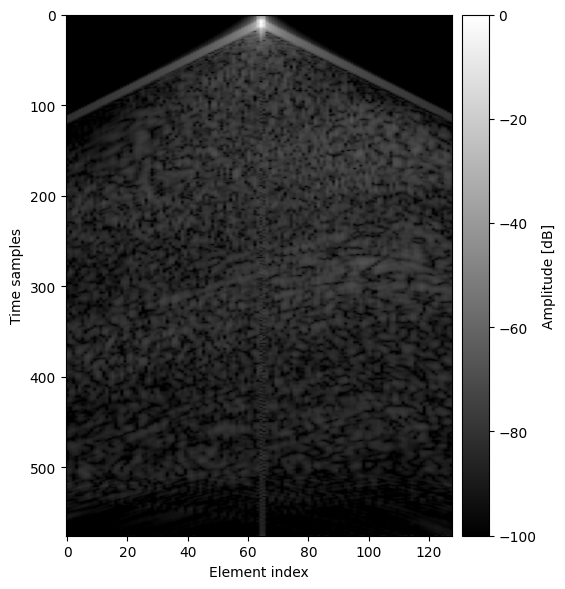

In [25]:
import matplotlib.pyplot as plt

# plot convert_to_db(iq_data[0, :, :, 0]).T,
plt.close("all")
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
im = ax.imshow(
    convert_to_db(iq_data[1, :, :, 0]).T,
    vmin=-100,
    vmax=0,
    aspect=0.3,
    cmap="gray",
)
ax.set_xlabel("Element index")
ax.set_ylabel("Time samples")
cbar = fig.colorbar(im, ax=ax, orientation="vertical", pad=0.02)
cbar.set_label("Amplitude [dB]")
# plt.subplots_adjust(left=0.05, right=1.08, top=0.95, bottom=0.15)
plt.tight_layout()
# plt.savefig(work_dir / "iq_data.svg", dpi=300)
plt.savefig("./temp/iq_data.png", dpi=300)

and here is the final B-mode image after envelope detection and log compression.


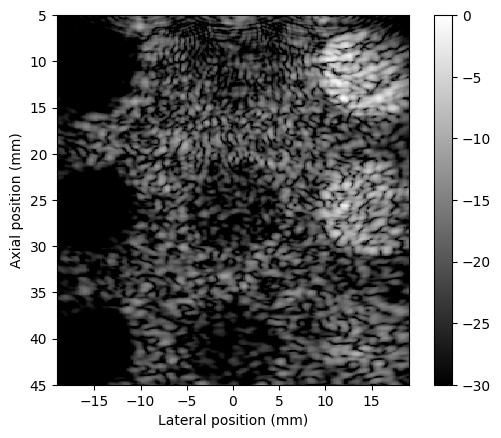

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [26]:
plot_utils.plot_array(
    convert_to_db(b_mode).T,
    vmin=-30,
    vmax=0,
    aspect=1,
    cmap="gray",
    extent=[
        b_mode_x[0] * 1e3,
        b_mode_x[-1] * 1e3,
        b_mode_z[-1] * 1e3,
        b_mode_z[0] * 1e3,
    ],
    xlabel="Lateral position (mm)",
    ylabel="Axial position (mm)",
    colorbar=True,
    export_path=work_dir / "beamformed_image.svg",
    show=True,
)

If needed you can store the results using your preferred method (e.g., saving as images or NumPy arrays). For example, for the npz format:


In [27]:
np.savez(
    work_dir / "simulation_data.npz",
    b_mode=b_mode,
    b_mode_x=b_mode_x,
    b_mode_z=b_mode_z,
    iq_data=iq_data,
)